In [27]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl joblib

In [28]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import joblib

from google.colab import files

In [29]:
# Upload the Excel file
uploaded = files.upload()

file_path = "/content/Prediction_Data.xlsx"

Saving Prediction_Data.xlsx to Prediction_Data.xlsx


In [30]:
# Load churn data
data = pd.read_excel(
    file_path,
    sheet_name="vw_ChurnData"
)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (6007, 32)


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11098-MAD,Female,30,Yes,Madhya Pradesh,0,31,Deal 1,Yes,No,...,Bank Withdrawal,95.099998,6683.399902,0.00,0,631.719971,7315.120117,Stayed,Others,Others
1,11114-PUN,Male,51,No,Punjab,5,9,Deal 5,Yes,No,...,Bank Withdrawal,49.150002,169.050003,0.00,10,122.370003,301.420013,Churned,Competitor,Competitor had better devices
2,11167-WES,Female,43,Yes,West Bengal,3,28,Deal 1,Yes,Yes,...,Bank Withdrawal,116.050003,8297.500000,42.57,110,1872.979980,10237.910156,Stayed,Others,Others
3,11179-MAH,Male,35,No,Maharashtra,10,12,NaN,Yes,No,...,Credit Card,84.400002,5969.299805,0.00,0,219.389999,6188.689941,Stayed,Others,Others
4,11180-TAM,Male,75,Yes,Tamil Nadu,12,27,Deal 2,Yes,No,...,Credit Card,72.599998,4084.350098,0.00,140,332.079987,4556.430176,Stayed,Others,Others


Data preprocessing

In [31]:
# Remove columns that are not required for prediction
data = data.drop(
    ["Customer_ID", "Churn_Category", "Churn_Reason"],
    axis=1
)

# Categorical columns to encode
columns_to_encode = [
    "Gender",
    "Married",
    "State",
    "Value_Deal",
    "Phone_Service",
    "Multiple_Lines",
    "Internet_Service",
    "Internet_Type",
    "Online_Security",
    "Online_Backup",
    "Device_Protection_Plan",
    "Premium_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Streaming_Music",
    "Unlimited_Data",
    "Contract",
    "Paperless_Billing",
    "Payment_Method"
]

# Encode categorical variables
label_encoders = {}

for column in columns_to_encode:
    encoder = LabelEncoder()
    data[column] = encoder.fit_transform(data[column])
    label_encoders[column] = encoder

# Encode target variable
data["Customer_Status"] = data["Customer_Status"].map({
    "Stayed": 0,
    "Churned": 1
})

Split the data

In [32]:
# Separate features and target
X = data.drop("Customer_Status", axis=1)
y = data["Customer_Status"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4805, 28)
Testing data: (1202, 28)


Train Random Forest

In [33]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


Evaluate the model

In [34]:
# Generate predictions
y_pred = rf_model.predict(X_test)

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[783  64]
 [126 229]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       847
           1       0.78      0.65      0.71       355

    accuracy                           0.84      1202
   macro avg       0.82      0.78      0.80      1202
weighted avg       0.84      0.84      0.84      1202



Feature importance

In [35]:
# Calculate feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
19,Contract,0.147150
27,Total_Revenue,0.140142
23,Total_Charges,0.122482
22,Monthly_Charge,0.088066
26,Total_Long_Distance_Charges,0.083507
1,Age,0.064996
5,Tenure_in_Months,0.046716
3,State,0.040922
4,Number_of_Referrals,0.038196
10,Internet_Type,0.028114


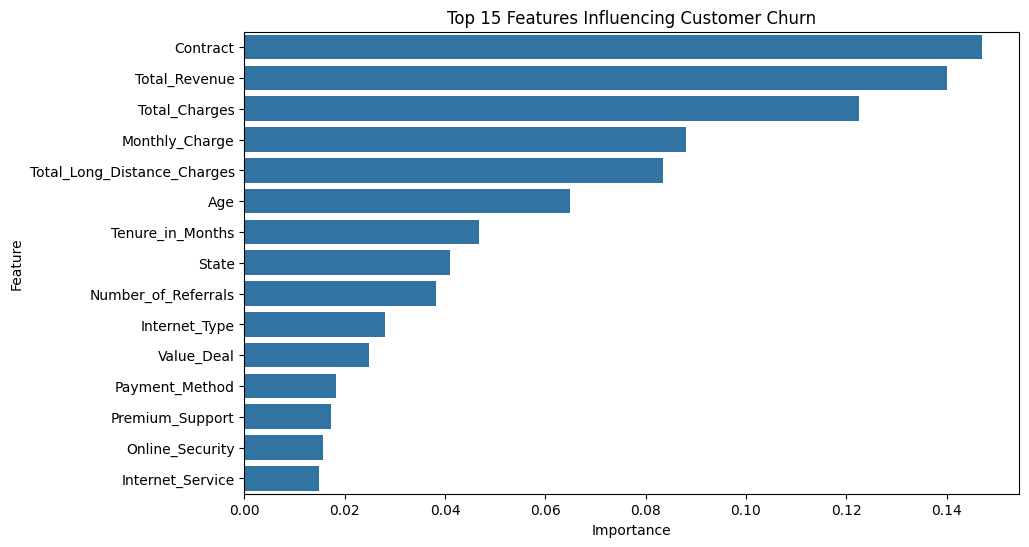

In [36]:
# Plot feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Customer Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Predict churn for new customers

In [37]:
# Load new customer data
new_data = pd.read_excel(
    file_path,
    sheet_name="vw_JoinData"
)

# Keep original data for the final output
original_data = new_data.copy()

# Remove columns not used for prediction
prediction_data = new_data.drop(
    [
        "Customer_ID",
        "Customer_Status",
        "Churn_Category",
        "Churn_Reason"
    ],
    axis=1
)

# Apply the same encoders used during training
for column in prediction_data.select_dtypes(
    include=["object"]
).columns:
    prediction_data[column] = label_encoders[column].transform(
        prediction_data[column]
    )

In [38]:
# Predict customer churn
predictions = rf_model.predict(prediction_data)

# Add predictions to the original data
original_data["Customer_Status_Predicted"] = predictions

# Keep only customers predicted to churn
churn_predictions = original_data[
    original_data["Customer_Status_Predicted"] == 1
]

print("Predicted churn customers:", len(churn_predictions))

churn_predictions.head()

Predicted churn customers: 378


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason,Customer_Status_Predicted
0,11751-TAM,Female,18,No,Tamil Nadu,5,7,Deal 5,No,No,...,24.299999,38.450001,0.0,0,0.000000,38.450001,Joined,Others,Others,1
1,12056-WES,Male,27,No,West Bengal,2,20,NaN,Yes,No,...,90.400002,268.450012,0.0,0,94.440002,362.890015,Joined,Others,Others,1
2,12136-RAJ,Female,25,Yes,Rajasthan,2,35,NaN,Yes,No,...,19.900000,19.900000,0.0,0,11.830000,31.730000,Joined,Others,Others,1
3,12257-ASS,Female,39,No,Assam,9,1,NaN,Yes,No,...,19.549999,19.549999,0.0,0,10.200000,29.750000,Joined,Others,Others,1
4,12340-DEL,Female,51,Yes,Delhi,0,10,NaN,Yes,No,...,62.799999,62.799999,0.0,0,42.189999,104.989998,Joined,Others,Others,1


Export the results

In [39]:
# Save predictions
output_file = "/content/Predictions.csv"

churn_predictions.to_csv(
    output_file,
    index=False
)

print("Predictions saved successfully.")

Predictions saved successfully.


In [40]:
# Download the prediction file
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>